# Crop to AOI

## Import libs

In [1]:
import os
import glob
import geopandas as gpd
import rioxarray as rxr
import matplotlib.pyplot as plt
from pathlib import Path

## Define File Paths

In [10]:
notebook_dir = Path.cwd()
base_path = notebook_dir.parent.parent / "Data" 
base_path_str = str(base_path)
print(f"Base path automatically set to: {base_path_str}")

Base path automatically set to: /net/home/sloeblein/Patras_Wildfire/Data


In [11]:
input_folder = os.path.join(base_path, "5_Added_CHM_Channel")
cropped_folder = os.path.join(base_path, "6_Cropped_Images")
os.makedirs(cropped_folder, exist_ok=True)
roi_path = os.path.join(input_folder, "final_cut.shp")

## Load ROI Data

ROI loaded. CRS: EPSG:4326


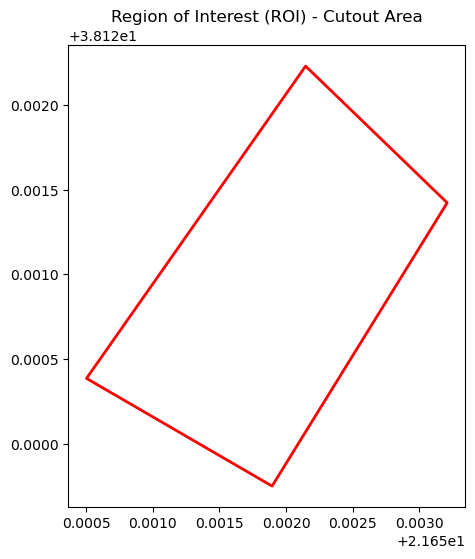

In [12]:
roi = gpd.read_file(roi_path)

print(f"ROI loaded. CRS: {roi.crs}")

roi.plot(edgecolor="red", facecolor="none", linewidth=2, figsize=(8, 6))
plt.title("Region of Interest (ROI) - Cutout Area")
plt.show()

## Cut all TIFs to ROI

In [ ]:
# 1. Get all TIFs
all_tifs = glob.glob(os.path.join(input_folder, "*.tif"))
print(f"Found TIF-Files to cut: {len(all_tifs)}\n")

cropped_files_paths = []

for file in all_tifs:
    basename = os.path.basename(file)
    print(f"Processing: {basename}...")
    
    # A) Load Raster image
    ds = rxr.open_rasterio(file)
    
    # B) CRS Check
    raster_crs = ds.rio.crs
    
    if roi.crs != raster_crs:
        print(f"  -> ⚠️ CRS Mismatch! Raster: {raster_crs} | ROI: {roi.crs}")
        print("  -> Transform shapefile to Raster-CRS...")
        roi_current = roi.to_crs(raster_crs)
    else:
        roi_current = roi
        
    # C) Cropping
    try:
        ds_cropped = ds.rio.clip(roi_current.geometry, roi_current.crs, drop=True)
        
        # D) Save
        output_path = os.path.join(output_folder, basename.replace(".tif", "_cropped.tif"))
        ds_cropped.rio.to_raster(output_path)
        cropped_files_paths.append(output_path)
        print(f"  -> ✅ Successfully cropped and saved!\n")
        
    except Exception as e:
        print(f"  -> ❌ Error during cropping of {basename}: {e}\n")
        
    finally:
        ds.close()
        if 'ds_cropped' in locals():
            ds_cropped.close()

print("All images were processed!")